In [16]:
!pip install ultralytics -q

In [17]:
!pip install torch torchvision Pillow -q

In [ ]:
!pip install easyocr -q

In [18]:
import torch
from PIL import Image

In [55]:
import cv2
import os
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from collections import defaultdict
from PIL import Image
import zipfile
import shutil
import easyocr

In [20]:
# Удалить старые предсказания
if os.path.exists('runs/detect/predict'):
    shutil.rmtree('runs/detect/predict')

In [21]:
from ultralytics import YOLO

In [22]:
model_path = '/kaggle/input/models/mashamalyshkina/lenta-yolo-model/pytorch/default/1/lenta_yolo_model.pt'

In [23]:
model = YOLO(model_path)

In [59]:
def preprocess_for_ocr(image, debug=False):
    
    # 1. Увеличение контраста
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)
    enhanced = cv2.merge([l_enhanced, a, b])
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)
    
    if debug:
        plt.figure(figsize=(15, 10))
        plt.subplot(2, 3, 1)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title('1. Оригинал')
        plt.axis('off')
    return enhanced

In [56]:
def preprocess_for_ocr(image, debug=False):
    """
    Комплексная предобработка изображения для улучшения OCR
    
    Args:
        image: исходное изображение (BGR)
        debug: если True, показывает промежуточные результаты
    
    Returns:
        preprocessed: обработанное изображение (grayscale или color)
    """
    
    # 1. Увеличение контраста
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)
    enhanced = cv2.merge([l_enhanced, a, b])
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)
    
    if debug:
        plt.figure(figsize=(15, 10))
        plt.subplot(2, 3, 1)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title('1. Оригинал')
        plt.axis('off')
    
    # 2. Преобразование в оттенки серого
    gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)
    
    if debug:
        plt.subplot(2, 3, 2)
        plt.imshow(gray, cmap='gray')
        plt.title('2. Оттенки серого')
        plt.axis('off')
    
    # 3. Бинаризация (Otsu + адаптивная)
    # Сначала Otsu для глобального порога
    _, binary_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Адаптивная бинаризация для локальных особенностей
    binary_adaptive = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 11, 2
    )
    
    # Комбинируем
    binary = cv2.bitwise_or(binary_otsu, binary_adaptive)
    
    if debug:
        plt.subplot(2, 3, 3)
        plt.imshow(binary, cmap='gray')
        plt.title('3. Бинаризация')
        plt.axis('off')
    
    # 4. Удаление шума
    denoised = cv2.medianBlur(binary, 3)
    denoised = cv2.GaussianBlur(denoised, (3, 3), 0)
    _, denoised = cv2.threshold(denoised, 127, 255, cv2.THRESH_BINARY)
    
    if debug:
        plt.subplot(2, 3, 4)
        plt.imshow(denoised, cmap='gray')
        plt.title('4. Удаление шума')
        plt.axis('off')
    
    # 5. Морфологические операции (закрытие дырок)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    closed = cv2.morphologyEx(denoised, cv2.MORPH_CLOSE, kernel)
    
    if debug:
        plt.subplot(2, 3, 5)
        plt.imshow(closed, cmap='gray')
        plt.title('5. Закрытие дырок')
        plt.axis('off')
    
    # 6. Увеличение разрешения (опционально)
    scale_factor = 2
    h, w = closed.shape[:2]
    upscaled = cv2.resize(closed, (w * scale_factor, h * scale_factor), 
                          interpolation=cv2.INTER_CUBIC)
    
    if debug:
        plt.subplot(2, 3, 6)
        plt.imshow(upscaled, cmap='gray')
        plt.title('6. Увеличение разрешения')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    return upscaled

In [24]:
# Функция для отрисовки тренировочных данных
def demonstrate_train_data(
    image_path: str,
    label_path: str
    ) -> Figure:

    # Загрузка изображения
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Конвертация в RGB для matplotlib
    h, w = image.shape[:2]

    # Чтение меток
    with open(label_path, 'r') as f:
        labels = f.readlines()

    # Отрисовка bounding boxes
    for label in labels:
        class_id, x_center, y_center, width, height = map(float, label.split())
        class_id = int(class_id)

        # Конвертация из YOLO-формата (нормированные координаты) в пиксели
        x_center *= w
        y_center *= h
        width *= w
        height *= h
        x1 = int(x_center - width/2)
        y1 = int(y_center - height/2)
        x2 = int(x_center + width/2)
        y2 = int(y_center + height/2)

        # Рисуем прямоугольник и подпись
        cv2.rectangle(image, (x1, y1), (x2, y2), colors[class_id], 10)
        cv2.putText(image, classes[class_id], (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 2, colors[class_id], 2)

    # Вывод изображения
    fig = plt.figure(figsize=(14,10))
    array = np.array(image)
    plt.imshow(array, cmap='gray')
    plt.colorbar()
    plt.axis('off')
    plt.close(fig)

    return fig

In [25]:
classes = ['price_tag']
colors = [(255,0,0)]

In [26]:
input_path = '/kaggle/input/datasets/mashamalyshkina/test-images/26_2-10.mp4_snapshot_00.03.519.jpg'

In [27]:
results = model.predict(
    source=input_path,
    conf=0.1,
    save=True,
    save_txt=True,
    # save_conf=False
)


image 1/1 /kaggle/input/datasets/mashamalyshkina/test-images/26_2-10.mp4_snapshot_00.03.519.jpg: 640x384 13 price tags, 72.5ms
Speed: 2.4ms preprocess, 72.5ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /kaggle/working/runs/detect/predict
1 label saved to /kaggle/working/runs/detect/predict/labels


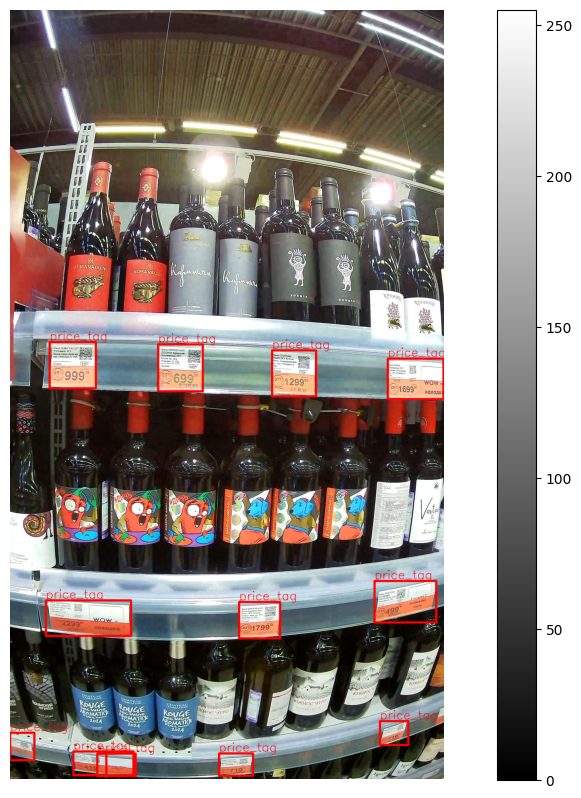

In [28]:
image_path = input_path
label_path = '/kaggle/working/runs/detect/predict/labels/26_2-10.mp4_snapshot_00.03.519.txt'

demonstrate_train_data(image_path, label_path)


image 1/1 /kaggle/input/datasets/mashamalyshkina/test-images/26_2-10.mp4_snapshot_00.12.195.jpg: 640x384 12 price tags, 65.0ms
Speed: 1.9ms preprocess, 65.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /kaggle/working/runs/detect/predict
1 label saved to /kaggle/working/runs/detect/predict/labels


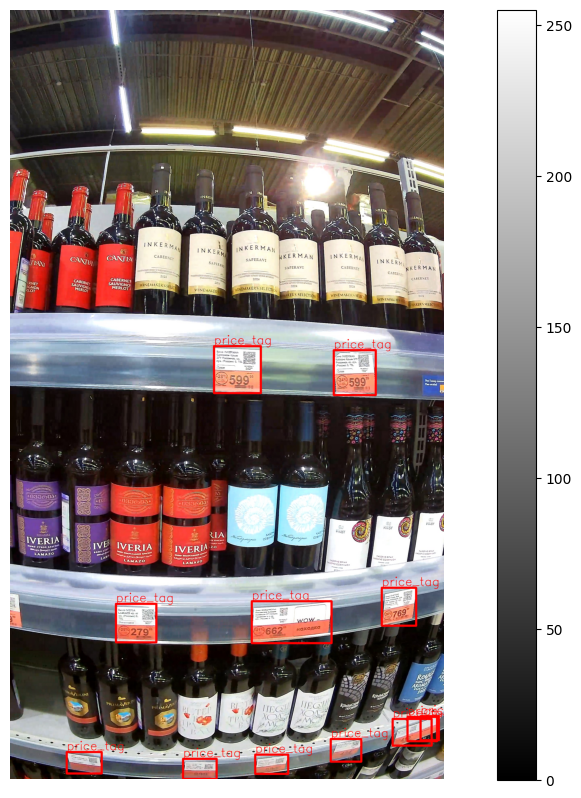

In [32]:
if os.path.exists('runs/detect/predict'):
    shutil.rmtree('runs/detect/predict')
    
input_path = '/kaggle/input/datasets/mashamalyshkina/test-images/26_2-10.mp4_snapshot_00.12.195.jpg'
results = model.predict(
    source=input_path,
    conf=0.1,
    save=True,
    save_txt=True
)

label_path = '/kaggle/working/runs/detect/predict/labels/26_2-10.mp4_snapshot_00.12.195.txt'
demonstrate_train_data(input_path, label_path)


image 1/1 /kaggle/input/datasets/mashamalyshkina/test-images/43_15.mp4_snapshot_00.00.000.jpg: 640x384 15 price tags, 80.2ms
Speed: 2.2ms preprocess, 80.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /kaggle/working/runs/detect/predict
1 label saved to /kaggle/working/runs/detect/predict/labels


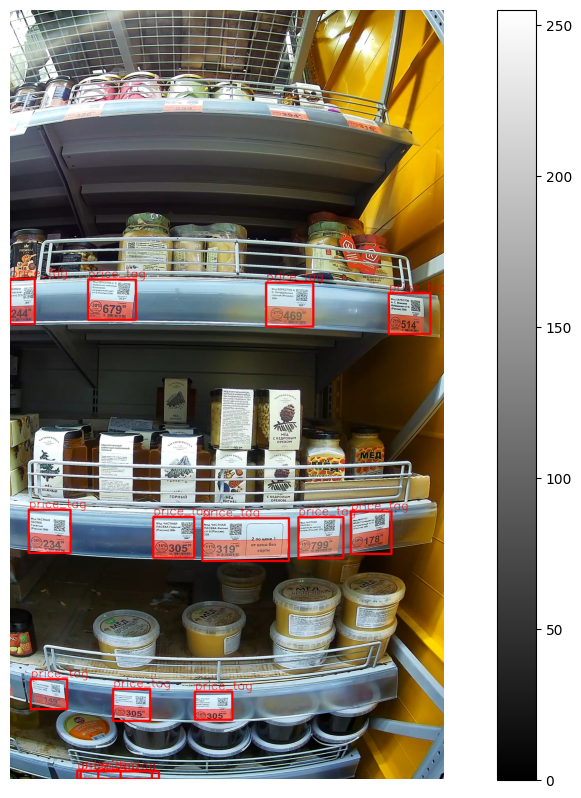

In [62]:
if os.path.exists('runs/detect/predict'):
    shutil.rmtree('runs/detect/predict')
    
input_path = '/kaggle/input/datasets/mashamalyshkina/test-images/43_15.mp4_snapshot_00.00.000.jpg'
results = model.predict(
    source=input_path,
    conf=0.1,
    save=True,
    save_txt=True
)

label_path = '/kaggle/working/runs/detect/predict/labels/43_15.mp4_snapshot_00.00.000.txt'
demonstrate_train_data(input_path, label_path)

In [63]:
# Инициализация OCR (русский + английский)
reader = easyocr.Reader(['ru', 'en'], gpu=False)

Using CPU. Note: This module is much faster with a GPU.


Ценник вырезан: (213, 431, 3)


(np.float64(-0.5), np.float64(430.5), np.float64(212.5), np.float64(-0.5))

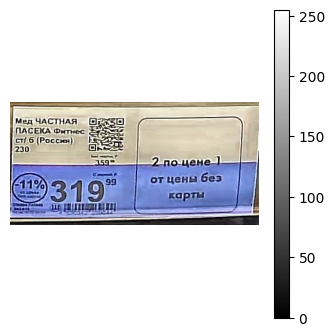

In [64]:
img = cv2.imread(input_path)
if len(results[0].boxes) > 0:
    # Берём первый (или самый уверенный) ценник
    box = results[0].boxes[0]
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    
    # Вырезаем область ценника
    price_tag = img[y1:y2, x1:x2]
    price_tag = preprocess_for_ocr(price_tag)
    
    # Сохраняем для отладки
    cv2.imwrite('/kaggle/working/price_tag_cropped.jpg', price_tag)
    print(f"Ценник вырезан: {price_tag.shape}")
else:
    print("Ценник не найден")

fig = plt.figure(figsize=(4,4))
array = np.array(price_tag)
plt.imshow(array, cmap='gray')
plt.colorbar()
plt.axis('off')

In [65]:
# Распознавание текста на вырезанном ценнике
result = reader.readtext(price_tag, detail=0, paragraph=False)

print("Распознанный текст:")
for line in result:
    print(f"  {line}")

Распознанный текст:
  Мед ЧАСТНАЯ
  ПА СЕIА Фнтнаc
  6 [Рассю)
  2J0
  2 по цене
  g9
  от цены без
  319
  карты
  шлшпиш


Ценник вырезан: (219, 235, 3)
Распознанный текст:
  Ися БЕРЕСТОВ
  таnнu1
  [Pu=u)
  50Jr
  2196]
  95
  469
  Нлрuuaч


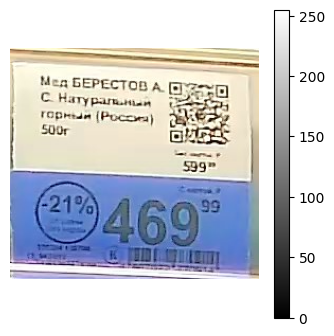

In [66]:
img = cv2.imread(input_path)
if len(results[0].boxes) > 0:
    box = results[0].boxes[1]
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    price_tag = img[y1:y2, x1:x2]
    cv2.imwrite('/kaggle/working/price_tag_cropped.jpg', price_tag)
    print(f"Ценник вырезан: {price_tag.shape}")
else:
    print("Ценник не найден")

fig = plt.figure(figsize=(4,4))
array = np.array(price_tag)
plt.imshow(array, cmap='gray')
plt.colorbar()
plt.axis('off')

result = reader.readtext(price_tag, detail=0, paragraph=False)
print("Распознанный текст:")
for line in result:
    print(f"  {line}")

Ценник вырезан: (204, 224, 3)
Распознанный текст:
  ue; ЧАЕПЫАЛ
  ПьtL
  nnun
  гяmam ;
  ~тctin (Гauq
  g9
  4573)
  799'
  шuц


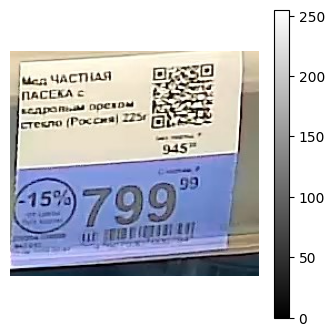

In [67]:
img = cv2.imread(input_path)
if len(results[0].boxes) > 0:
    box = results[0].boxes[2]
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    price_tag = img[y1:y2, x1:x2]
    cv2.imwrite('/kaggle/working/price_tag_cropped.jpg', price_tag)
    print(f"Ценник вырезан: {price_tag.shape}")
else:
    print("Ценник не найден")

fig = plt.figure(figsize=(4,4))
array = np.array(price_tag)
plt.imshow(array, cmap='gray')
plt.colorbar()
plt.axis('off')

result = reader.readtext(price_tag, detail=0, paragraph=False)
print("Распознанный текст:")
for line in result:
    print(f"  {line}")

Ценник вырезан: (215, 208, 3)
Распознанный текст:
  П СЕКА
  Таслным
  suOr
  369
  в1
  234
  Wrд '
  ЧАСТНЕЯ
  [Poct-u)


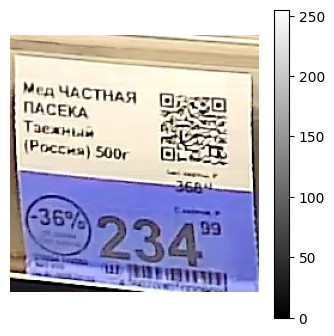

In [68]:
img = cv2.imread(input_path)
if len(results[0].boxes) > 0:
    box = results[0].boxes[3]
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    price_tag = img[y1:y2, x1:x2]
    cv2.imwrite('/kaggle/working/price_tag_cropped.jpg', price_tag)
    print(f"Ценник вырезан: {price_tag.shape}")
else:
    print("Ценник не найден")

fig = plt.figure(figsize=(4,4))
array = np.array(price_tag)
plt.imshow(array, cmap='gray')
plt.colorbar()
plt.axis('off')

result = reader.readtext(price_tag, detail=0, paragraph=False)
print("Распознанный текст:")
for line in result:
    print(f"  {line}")

Ценник вырезан: (203, 207, 3)
Распознанный текст:
  C .aa
  Wtaazer
  сы
  (~21PA
  514
  ЕЕFЕCтО8
  a1б
  (Росьщ)


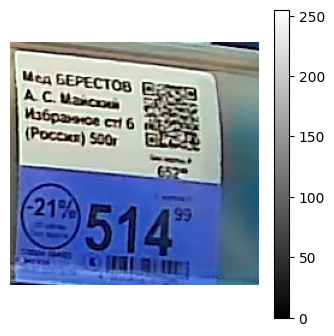

In [69]:
img = cv2.imread(input_path)
if len(results[0].boxes) > 0:
    box = results[0].boxes[4]
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    price_tag = img[y1:y2, x1:x2]
    cv2.imwrite('/kaggle/working/price_tag_cropped.jpg', price_tag)
    print(f"Ценник вырезан: {price_tag.shape}")
else:
    print("Ценник не найден")

fig = plt.figure(figsize=(4,4))
array = np.array(price_tag)
plt.imshow(array, cmap='gray')
plt.colorbar()
plt.axis('off')

result = reader.readtext(price_tag, detail=0, paragraph=False)
print("Распознанный текст:")
for line in result:
    print(f"  {line}")

Ценник вырезан: (211, 202, 3)
Распознанный текст:
  Zun
  uEПA
  IГг
  MAСIЕР
  Ius
  '1789
  199
  ШIп


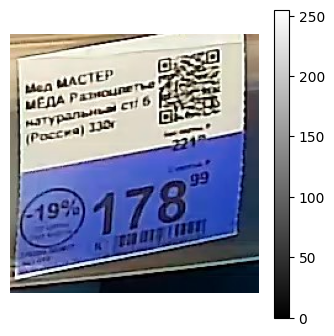

In [70]:
img = cv2.imread(input_path)
if len(results[0].boxes) > 0:
    box = results[0].boxes[5]
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    price_tag = img[y1:y2, x1:x2]
    cv2.imwrite('/kaggle/working/price_tag_cropped.jpg', price_tag)
    print(f"Ценник вырезан: {price_tag.shape}")
else:
    print("Ценник не найден")

fig = plt.figure(figsize=(4,4))
array = np.array(price_tag)
plt.imshow(array, cmap='gray')
plt.colorbar()
plt.axis('off')

result = reader.readtext(price_tag, detail=0, paragraph=False)
print("Распознанный текст:")
for line in result:
    print(f"  {line}")

Ценник вырезан: (203, 203, 3)
Распознанный текст:
  Нш ЧАСТНАЯ
  gie
  ПАСЕЮА Гарм чм
  [Россич| S0Dr
  1Gi
  16%
  99
  3055


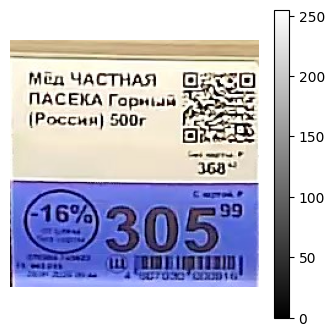

In [71]:
img = cv2.imread(input_path)
if len(results[0].boxes) > 0:
    box = results[0].boxes[6]
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    price_tag = img[y1:y2, x1:x2]
    cv2.imwrite('/kaggle/working/price_tag_cropped.jpg', price_tag)
    print(f"Ценник вырезан: {price_tag.shape}")
else:
    print("Ценник не найден")

fig = plt.figure(figsize=(4,4))
array = np.array(price_tag)
plt.imshow(array, cmap='gray')
plt.colorbar()
plt.axis('off')

result = reader.readtext(price_tag, detail=0, paragraph=False)
print("Распознанный текст:")
for line in result:
    print(f"  {line}")

Ценник вырезан: (201, 238, 3)
Распознанный текст:
  FELTCП ^ €
  IL-агзa Iяпаш .
  1iП'/
  Kатуi~iin
  LNE |
  [Ра=Euч) > 3г
  ar-
  97J
  30%
  99
  679
  ШШ


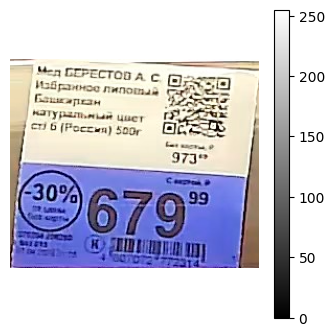

In [72]:
img = cv2.imread(input_path)
if len(results[0].boxes) > 0:
    box = results[0].boxes[7]
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    price_tag = img[y1:y2, x1:x2]
    cv2.imwrite('/kaggle/working/price_tag_cropped.jpg', price_tag)
    print(f"Ценник вырезан: {price_tag.shape}")
else:
    print("Ценник не найден")

fig = plt.figure(figsize=(4,4))
array = np.array(price_tag)
plt.imshow(array, cmap='gray')
plt.colorbar()
plt.axis('off')

result = reader.readtext(price_tag, detail=0, paragraph=False)
print("Распознанный текст:")
for line in result:
    print(f"  {line}")

Ценник вырезан: (140, 186, 3)
Распознанный текст:
  nraAol
  305


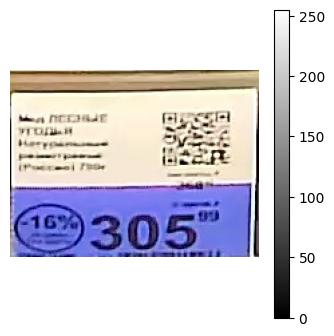

In [73]:
img = cv2.imread(input_path)
if len(results[0].boxes) > 0:
    box = results[0].boxes[8]
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    price_tag = img[y1:y2, x1:x2]
    cv2.imwrite('/kaggle/working/price_tag_cropped.jpg', price_tag)
    print(f"Ценник вырезан: {price_tag.shape}")
else:
    print("Ценник не найден")

fig = plt.figure(figsize=(4,4))
array = np.array(price_tag)
plt.imshow(array, cmap='gray')
plt.colorbar()
plt.axis('off')

result = reader.readtext(price_tag, detail=0, paragraph=False)
print("Распознанный текст:")
for line in result:
    print(f"  {line}")

Ценник вырезан: (159, 184, 3)
Распознанный текст:
  305


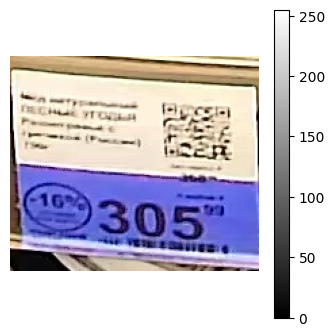

In [74]:
img = cv2.imread(input_path)
if len(results[0].boxes) > 0:
    box = results[0].boxes[9]
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    price_tag = img[y1:y2, x1:x2]
    cv2.imwrite('/kaggle/working/price_tag_cropped.jpg', price_tag)
    print(f"Ценник вырезан: {price_tag.shape}")
else:
    print("Ценник не найден")

fig = plt.figure(figsize=(4,4))
array = np.array(price_tag)
plt.imshow(array, cmap='gray')
plt.colorbar()
plt.axis('off')

result = reader.readtext(price_tag, detail=0, paragraph=False)
print("Распознанный текст:")
for line in result:
    print(f"  {line}")

Ценник вырезан: (149, 181, 3)
Распознанный текст:
  149


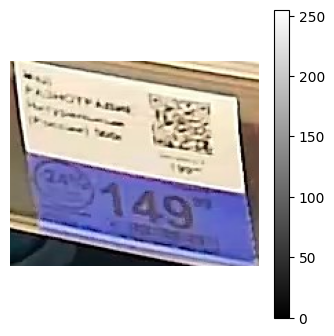

In [75]:
img = cv2.imread(input_path)
if len(results[0].boxes) > 0:
    box = results[0].boxes[10]
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    price_tag = img[y1:y2, x1:x2]
    cv2.imwrite('/kaggle/working/price_tag_cropped.jpg', price_tag)
    print(f"Ценник вырезан: {price_tag.shape}")
else:
    print("Ценник не найден")

fig = plt.figure(figsize=(4,4))
array = np.array(price_tag)
plt.imshow(array, cmap='gray')
plt.colorbar()
plt.axis('off')

result = reader.readtext(price_tag, detail=0, paragraph=False)
print("Распознанный текст:")
for line in result:
    print(f"  {line}")

Ценник вырезан: (225, 123, 3)
Распознанный текст:
  FEUIU
  Е Crtuu
  ЕЕня) u5г
  1D5
  59
  244


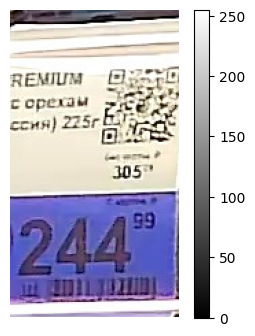

In [76]:
img = cv2.imread(input_path)
if len(results[0].boxes) > 0:
    box = results[0].boxes[11]
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    price_tag = img[y1:y2, x1:x2]
    cv2.imwrite('/kaggle/working/price_tag_cropped.jpg', price_tag)
    print(f"Ценник вырезан: {price_tag.shape}")
else:
    print("Ценник не найден")

fig = plt.figure(figsize=(4,4))
array = np.array(price_tag)
plt.imshow(array, cmap='gray')
plt.colorbar()
plt.axis('off')

result = reader.readtext(price_tag, detail=0, paragraph=False)
print("Распознанный текст:")
for line in result:
    print(f"  {line}")